In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import hdbscan
import umap
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore

Dataset: <br>
League - New All, Expanded Features <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v5/All_Data_Final_Fixed.csv')
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Force IDs and Events to string for reliable mapping
df['Game_ID'] = df['Game_ID'].astype(str).str.strip()
df['Event_Type'] = df['Event_Type'].astype(str).str.strip()

# Determine Outcomes for Supervised UMAP Guidance
final_results = df[df['Event_Type'].str.contains('FINAL RESULT', case=False, na=False)].copy()
conditions = [
    (final_results['Home_Score'] > final_results['Away_Score']),
    (final_results['Away_Score'] > final_results['Home_Score']),
    (final_results['Home_Score'] == final_results['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
final_results['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')

outcome_map = dict(zip(final_results['Game_ID'], final_results['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Clean and Filter: Remove unknowns and result rows to prevent leakage
df = df.dropna(subset=['Match_Outcomes'])
df = df[df['Match_Outcomes'] != 'Unknown'].copy()
df_mod = df[~df['Event_Type'].str.contains('Final Result', case=False, na=False)].copy()

# Feature Engineering
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Odds_Log'] = np.log1p(df_mod['Odds_Home_Win'].fillna(0))
df_mod['Draw_Odds_Log'] = np.log1p(df_mod['Odds_Draw'].fillna(0))
df_mod['Away_Odds_Log'] = np.log1p(df_mod['Odds_Away_Win'].fillna(0))

features = [
    'Time_Bin', 'Score_Diff', 'Home_Red_Count', 'Away_Red_Count', 
    'Home_Yellow_Count', 'Away_Yellow_Count', 'Home_Defensive_Sub_Count', 
    'Home_Offensive_Sub_Count', 'Away_Defensive_Sub_Count', 'Away_Offensive_Sub_Count',
    'Home_Odds_Log', 'Draw_Odds_Log', 'Away_Odds_Log'
]
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X + np.random.normal(0, 1e-5, X.shape))

--- Stage 1: Running Baseline ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


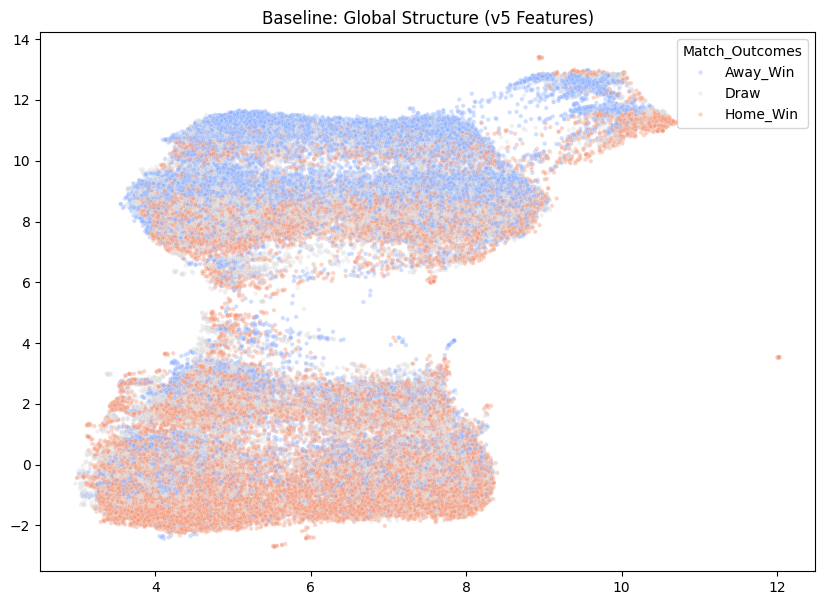


REASONING FOR NEXT STEP:
The baseline shows significant overlap. To identify specific tactical islands, we move to
Supervised UMAP in both 2D and 3D. This forces the model to prioritize feature patterns
that actually differentiate match results.


In [3]:
# STAGE 1: BASELINE (Unsupervised Global Structure)
# =================================================================
print("--- Stage 1: Running Baseline ---")
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='canberra', init='random', random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=10, alpha=0.4, palette='coolwarm')
plt.title("Baseline: Global Structure (v5 Features)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline shows significant overlap. To identify specific tactical islands, we move to")
print("Supervised UMAP in both 2D and 3D. This forces the model to prioritize feature patterns")
print("that actually differentiate match results.")


--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


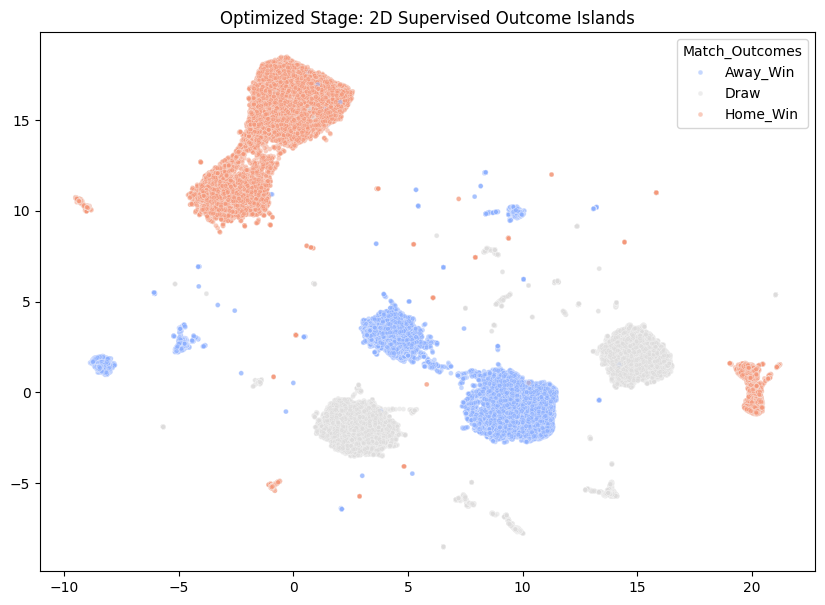

In [4]:
# STAGE 2: OPTIMIZED (2D & 3D Supervised Islands)
# =================================================================
print("\n--- Stage 2: Supervised 2D & 3D UMAP + HDBSCAN ---")
y_encoded, _ = pd.factorize(y_true)

# --- 2D SUPERVISED PROJECTION ---
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, target_weight=0.9, metric='canberra', init='random', random_state=42)
X_umap_2d = reducer_2d.fit_transform(X_scaled, y=y_encoded)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.5, palette='coolwarm')
plt.title("Optimized Stage: 2D Supervised Outcome Islands")
plt.show()

C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


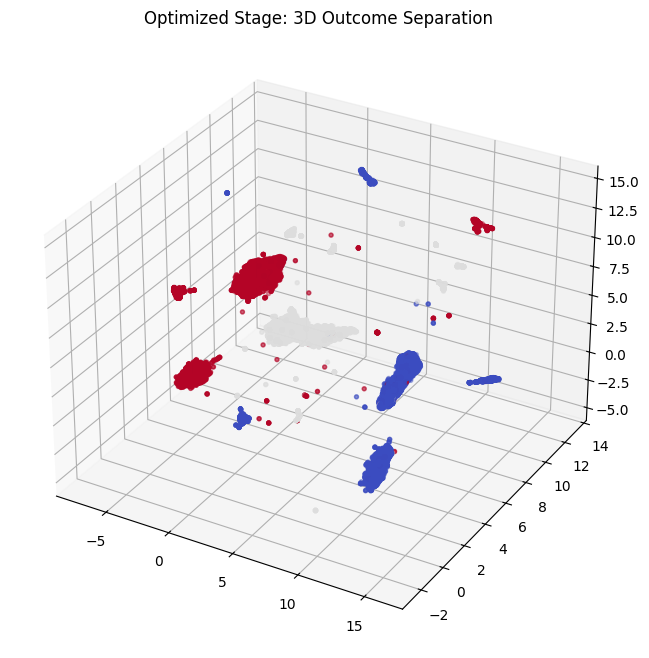

In [5]:
# --- 3D SUPERVISED PROJECTION ---
reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.0, target_weight=0.9, metric='canberra', init='random', random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_scaled, y=y_encoded)

# Clustering on 3D Space (Captures depth and density better)
clusterer = hdbscan.HDBSCAN(min_cluster_size=80, min_samples=15, cluster_selection_method='eom')
labels_opt = clusterer.fit_predict(X_umap_3d)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
color_map = {'Home_Win': '#3b4cc0', 'Away_Win': '#b40426', 'Draw': '#dddddd'}
colors = [color_map[val] for val in y_true]
ax.scatter(X_umap_3d[:, 0], X_umap_3d[:, 1], X_umap_3d[:, 2], c=colors, s=8, alpha=0.4)
plt.title("Optimized Stage: 3D Outcome Separation")
plt.show()


--- Stage 3: Tactical Archetype Signatures ---


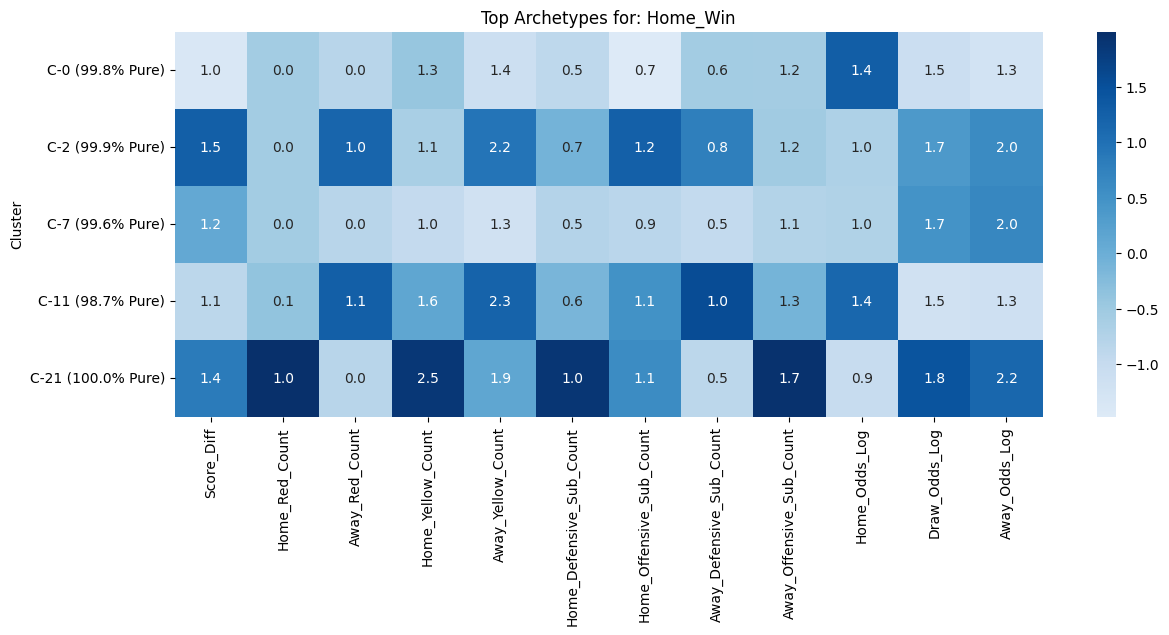

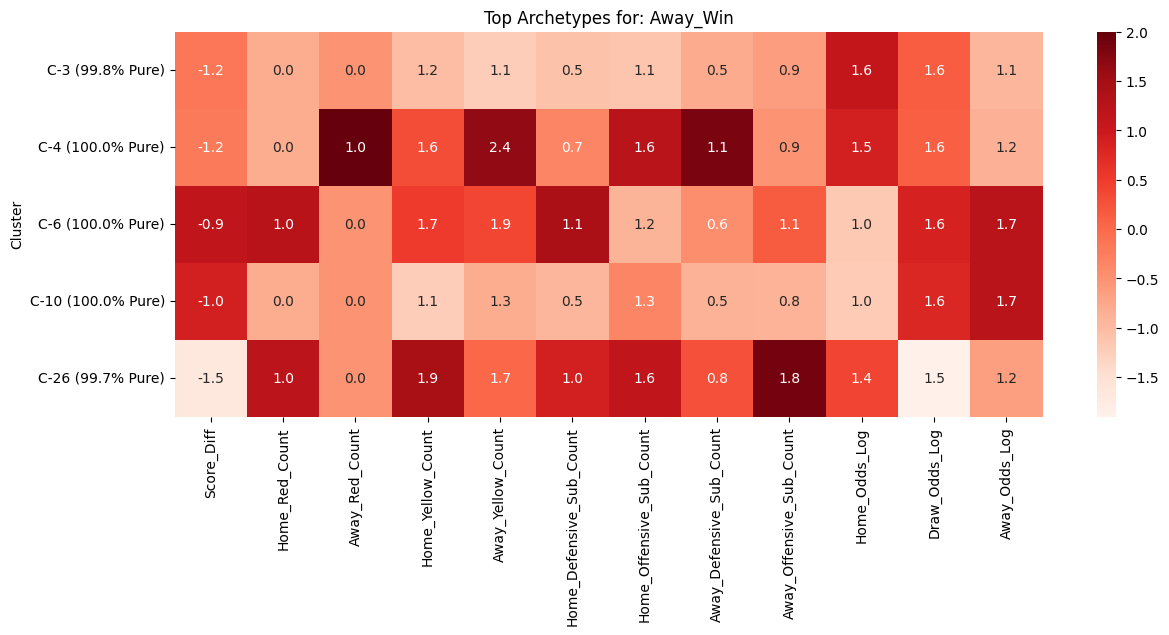

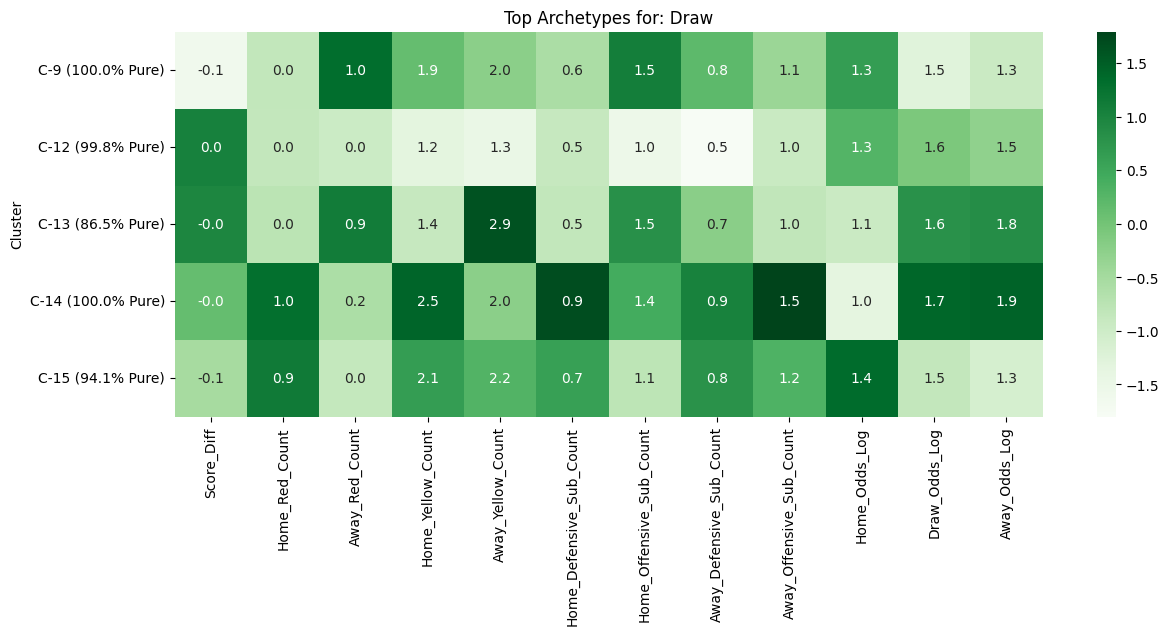

In [6]:
# STAGE 3: OUTCOME-SPECIFIC ARCHETYPES
# =================================================================
print("\n--- Stage 3: Tactical Archetype Signatures ---")
analysis_df = X.copy()
analysis_df['Cluster'], analysis_df['Outcome'] = labels_opt, y_true.values
purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
dominant_outcome = purity.idxmax(axis=1)

def plot_archetypes(target, cmap):
    rel_ids = purity.index[(dominant_outcome == target) & (purity.index != -1)]
    top_ids = analysis_df[analysis_df['Cluster'].isin(rel_ids)]['Cluster'].value_counts().iloc[:5].index
    if len(top_ids) > 0:
        stats = analysis_df[analysis_df['Cluster'].isin(top_ids)].groupby('Cluster').mean(numeric_only=True).drop(columns=['Time_Bin'])
        labels = [f"C-{idx} ({purity.loc[idx, target]*100:.1f}% Pure)" for idx in stats.index]
        plt.figure(figsize=(14, 5))
        sns.heatmap(stats.apply(zscore).fillna(0), annot=stats, fmt=".1f", cmap=cmap, center=0, yticklabels=labels)
        plt.title(f"Top Archetypes for: {target}")
        plt.show()

for out, cm in zip(['Home_Win', 'Away_Win', 'Draw'], ['Blues', 'Reds', 'Greens']):
    plot_archetypes(out, cm)


--- Stage 4: Spatial Mapping with Arrows ---


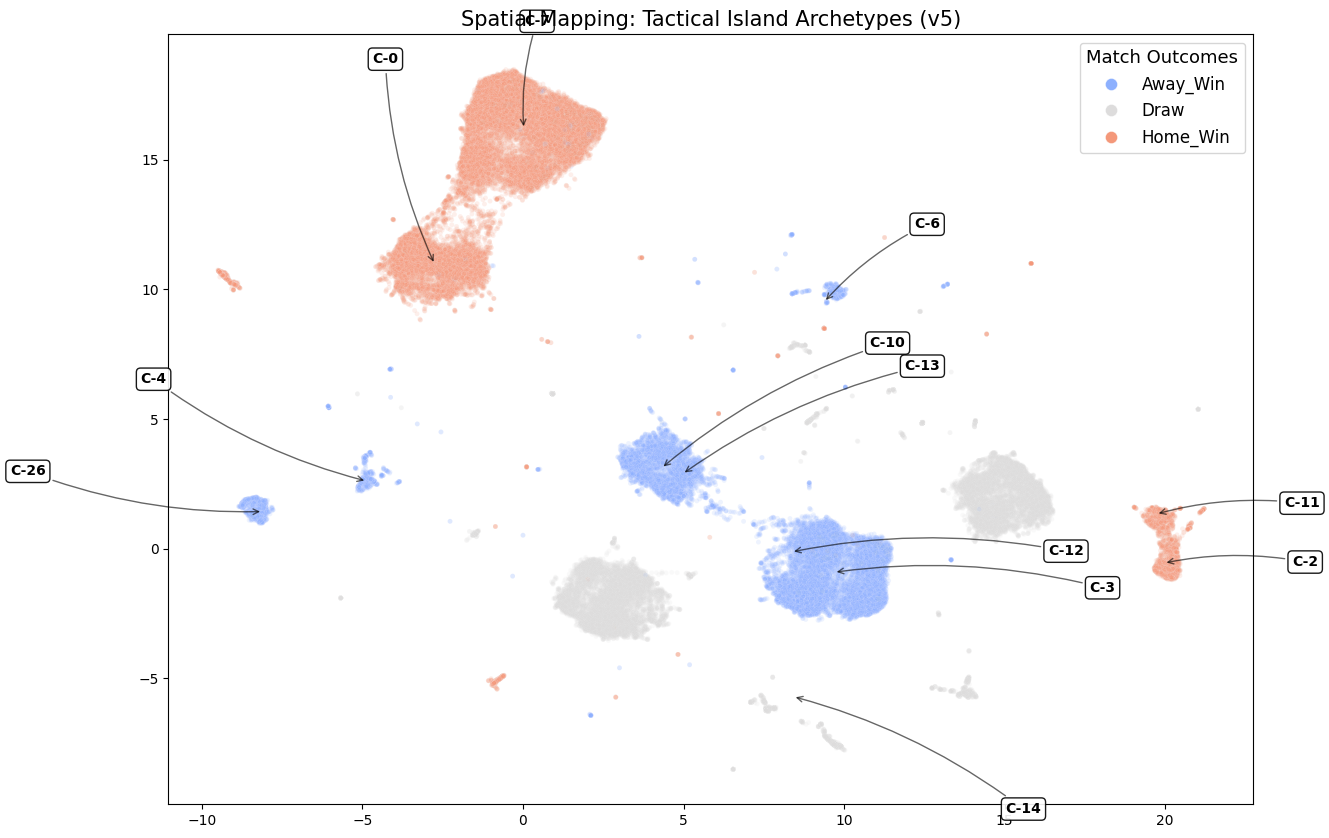

In [7]:
# STAGE 4: FINAL SPATIAL MAPPING (WITH ARROWS)
# =================================================================
print("\n--- Stage 4: Spatial Mapping with Arrows ---")

plt.figure(figsize=(14, 10))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=y_true, s=12, alpha=0.15, palette='coolwarm')

# Labeling Top Archetypes (Identifying only pure clusters found in Stage 3)
identified_clusters = analysis_df[analysis_df['Cluster'] != -1]['Cluster'].value_counts().iloc[:12].index
for cid in identified_clusters:
    mask = (labels_opt == cid)
    cx, cy = X_umap_2d[mask, 0].mean(), X_umap_2d[mask, 1].mean()
    
    # Distance-adaptive push logic
    dist = np.sqrt(cx**2 + cy**2)
    angle = np.arctan2(cy, cx)
    push = 4.0 if dist > 12 else 8.0
    
    plt.annotate(f"C-{cid}", xy=(cx, cy), xytext=(cx + push*np.cos(angle), cy + push*np.sin(angle)),
                 fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.3'),
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.1", color='black', alpha=0.6))

# High-contrast legend
leg = plt.legend(title="Match Outcomes", loc='upper right', markerscale=2.5, fontsize=12, title_fontsize=13)
for lh in leg.legend_handles: lh.set_alpha(1.0)
plt.title("Spatial Mapping: Tactical Island Archetypes (v5)", fontsize=15)
plt.show()